# 서울시 환경점수 가중치 비교: 균등 / PCA / CRITIC / ENTROPY

| 방법 | 원리 | 특징 |
|------|------|------|
| **균등(Equal)** | 1/n 고정 | 현재 파일 기준 |
| **PCA** | 1번 주성분의 적재량 | 분산을 가장 많이 설명하는 방향 |
| **CRITIC** | 표준편차 × 상관 기반 정보량 | 변동성 + 비상관성 동시 반영 |
| **ENTROPY** | 정보 엔트로피 역수 | 분포가 고를수록 낮은 가중치 |

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv(
    r'C:\8ssible-Healing-Seoul-Analysis\KM\서울시_환경점수_무가중치.csv',
    encoding='utf-8-sig'
)
df.columns = ['자치구','year_month','강수량점수','대기점수','불쾌지수점수','쓰레기점수','이상기온점수','환경점수_균등']

COMP_COLS = ['강수량점수','대기점수','불쾌지수점수','쓰레기점수','이상기온점수']
X = df[COMP_COLS].copy()

print(f'데이터: {len(df)}행  |  자치구: {df["자치구"].nunique()}개  |  기간: {df["year_month"].nunique()}개월')
display(X.describe().round(2))

데이터: 900행  |  자치구: 25개  |  기간: 36개월


,강수량점수,대기점수,불쾌지수점수,쓰레기점수,이상기온점수
count,900.00,900.00,900.00,900.00,900.00
mean,16.54,66.87,46.17,73.33,23.06
std,18.72,11.91,24.94,14.90,19.68
min,0.00,18.35,0.00,21.90,0.00
25%,0.67,57.71,23.54,65.64,10.45
50%,9.04,67.74,43.46,76.33,17.91
75%,25.10,76.24,70.07,83.83,28.36
max,98.38,90.90,100.00,97.65,100.00


---
## 1. 가중치 산출
### 1-1. PCA 가중치
표준화 후 PCA → 1번 주성분 적재량(절댓값) 비율

In [12]:
X_std = StandardScaler().fit_transform(X)
pca = PCA().fit(X_std)

pc1_abs = np.abs(pca.components_[0])
w_pca = pd.Series(pc1_abs / pc1_abs.sum(), index=COMP_COLS)

print(f'PC1 설명 분산: {pca.explained_variance_ratio_[0]:.1%}')
print(w_pca.round(4).to_string())

PC1 설명 분산: 57.2%
강수량점수     0.2345
대기점수      0.2313
불쾌지수점수    0.2588
쓰레기점수     0.0495
이상기온점수    0.2259


### 1-2. CRITIC 가중치
표준화 기반 표준편차(대비 강도) × 상관 비유사성의 합

In [13]:
def critic_weights(X):
    Xn = (X - X.min()) / (X.max() - X.min())
    std  = Xn.std()
    corr = Xn.corr().abs()
    info = std * (1 - corr).sum()
    return info / info.sum()

w_critic = critic_weights(X)
print(w_critic.round(4).to_string())

강수량점수     0.1625
대기점수      0.1533
불쾌지수점수    0.1944
쓰레기점수     0.3021
이상기온점수    0.1877


### 1-3. ENTROPY 가중치
엔트로피 e_j 계산 후 다양성 지수 (1 - e_j) 비율

In [14]:
def entropy_weights(X):
    Xn = (X - X.min()) / (X.max() - X.min()) + 1e-10
    p  = Xn.div(Xn.sum())
    k  = 1 / np.log(len(X))
    e  = -k * (p * np.log(p)).sum()
    d  = 1 - e
    return d / d.sum()

w_entropy = entropy_weights(X)
print(w_entropy.round(4).to_string())

강수량점수     0.5109
대기점수      0.0276
불쾌지수점수    0.1396
쓰레기점수     0.0436
이상기온점수    0.2784


---
## 2. 가중치 시각화 비교

,균등,PCA,CRITIC,ENTROPY
강수량점수,0.2,0.2345,0.1625,0.5109
대기점수,0.2,0.2313,0.1533,0.0276
불쾌지수점수,0.2,0.2588,0.1944,0.1396
쓰레기점수,0.2,0.0495,0.3021,0.0436
이상기온점수,0.2,0.2259,0.1877,0.2784


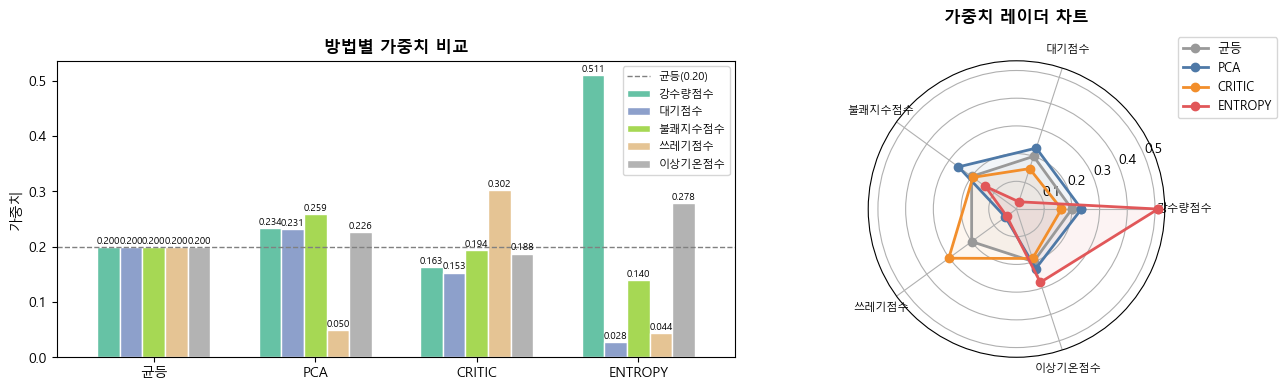

In [15]:
n = len(COMP_COLS)
w_equal = pd.Series([1/n]*n, index=COMP_COLS)

weight_df = pd.DataFrame({
    '균등': w_equal, 'PCA': w_pca,
    'CRITIC': w_critic, 'ENTROPY': w_entropy,
}).round(4)
display(weight_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

weight_df.T.plot(kind='bar', ax=axes[0], width=0.7, colormap='Set2', edgecolor='white')
axes[0].axhline(1/n, color='gray', linestyle='--', linewidth=1, label=f'균등({1/n:.2f})')
axes[0].set_title('방법별 가중치 비교', fontweight='bold')
axes[0].set_ylabel('가중치'); axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(fontsize=8)
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.3f', fontsize=7, padding=1)

# 레이더 차트
angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
angles_c = angles + angles[:1]
ax2 = fig.add_subplot(1,2,2, polar=True)
axes[1].remove()
colors = ['#999999','#4e79a7','#f28e2b','#e15759']
for (method, ws), color in zip(weight_df.T.iterrows(), colors):
    vals = ws.tolist() + ws.tolist()[:1]
    ax2.plot(angles_c, vals, 'o-', lw=2, label=method, color=color)
    ax2.fill(angles_c, vals, alpha=0.07, color=color)
ax2.set_xticks(angles); ax2.set_xticklabels(COMP_COLS, fontsize=8)
ax2.set_title('가중치 레이더 차트', fontweight='bold', pad=15)
ax2.legend(loc='upper right', bbox_to_anchor=(1.4,1.1), fontsize=9)

plt.tight_layout(); plt.show()

---
## 3. 방법별 종합 환경점수 산출 및 분포

,환경점수_균등,환경점수_PCA,환경점수_CRITIC,환경점수_ENTROPY
count,900.00,900.00,900.00,900.00
mean,45.20,40.14,48.40,26.35
std,5.60,5.59,5.82,10.85
min,28.15,27.79,27.63,11.27
25%,41.55,36.55,44.87,18.18
50%,44.81,39.57,48.48,23.09
75%,48.35,42.74,52.26,31.29
max,66.19,63.78,67.98,69.41


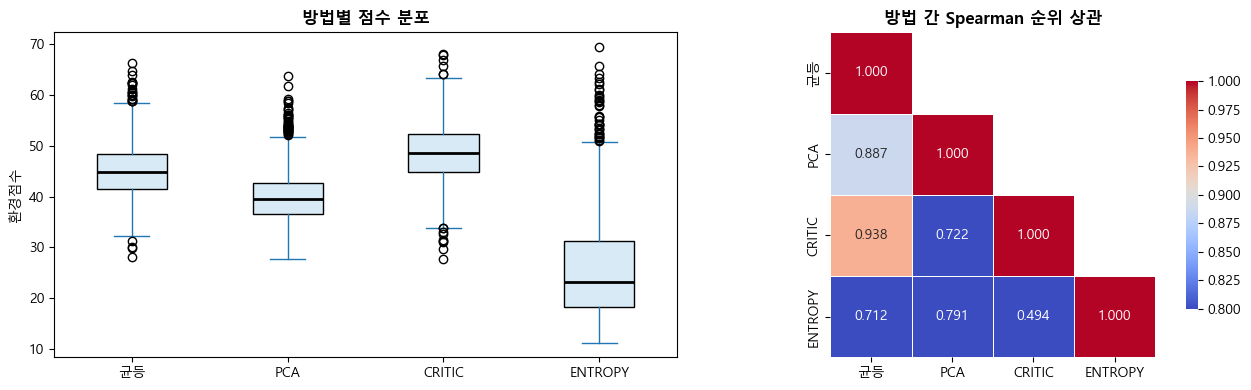

In [16]:
df['환경점수_PCA']     = (X * w_pca).sum(axis=1)
df['환경점수_CRITIC']  = (X * w_critic).sum(axis=1)
df['환경점수_ENTROPY'] = (X * w_entropy).sum(axis=1)

SCORE_COLS = ['환경점수_균등','환경점수_PCA','환경점수_CRITIC','환경점수_ENTROPY']

display(df[SCORE_COLS].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df[SCORE_COLS].plot(kind='box', ax=axes[0], patch_artist=True,
    boxprops=dict(facecolor='#d9eaf7'),
    medianprops=dict(color='black', linewidth=2))
axes[0].set_xticklabels([c.replace('환경점수_','') for c in SCORE_COLS])
axes[0].set_title('방법별 점수 분포', fontweight='bold')
axes[0].set_ylabel('환경점수')

spear = pd.DataFrame(index=SCORE_COLS, columns=SCORE_COLS, dtype=float)
for c1 in SCORE_COLS:
    for c2 in SCORE_COLS:
        r, _ = spearmanr(df[c1], df[c2])
        spear.loc[c1,c2] = round(r,3)
spear.index = spear.columns = [c.replace('환경점수_','') for c in SCORE_COLS]

mask = np.triu(np.ones_like(spear, dtype=bool), k=1)
sns.heatmap(spear, ax=axes[1], annot=True, fmt='.3f',
    cmap='coolwarm', vmin=0.8, vmax=1.0, mask=mask,
    square=True, linewidths=0.5, cbar_kws={'shrink':0.7})
axes[1].set_title('방법 간 Spearman 순위 상관', fontweight='bold')

plt.tight_layout(); plt.show()

---
## 4. 자치구별 연평균 점수 및 순위 비교

,균등,PCA,CRITIC,ENTROPY
자치구,,,,
강서구,38.20,39.19,37.71,24.48
강남구,39.69,40.16,39.11,28.42
중구,42.10,38.75,44.12,25.46
양천구,42.82,38.41,45.57,25.07
서초구,42.96,39.82,44.87,25.98
송파구,43.25,40.12,45.15,27.26
마포구,43.30,38.72,46.10,25.37
영등포구,43.57,37.72,47.15,24.40
노원구,44.13,40.70,46.24,27.96


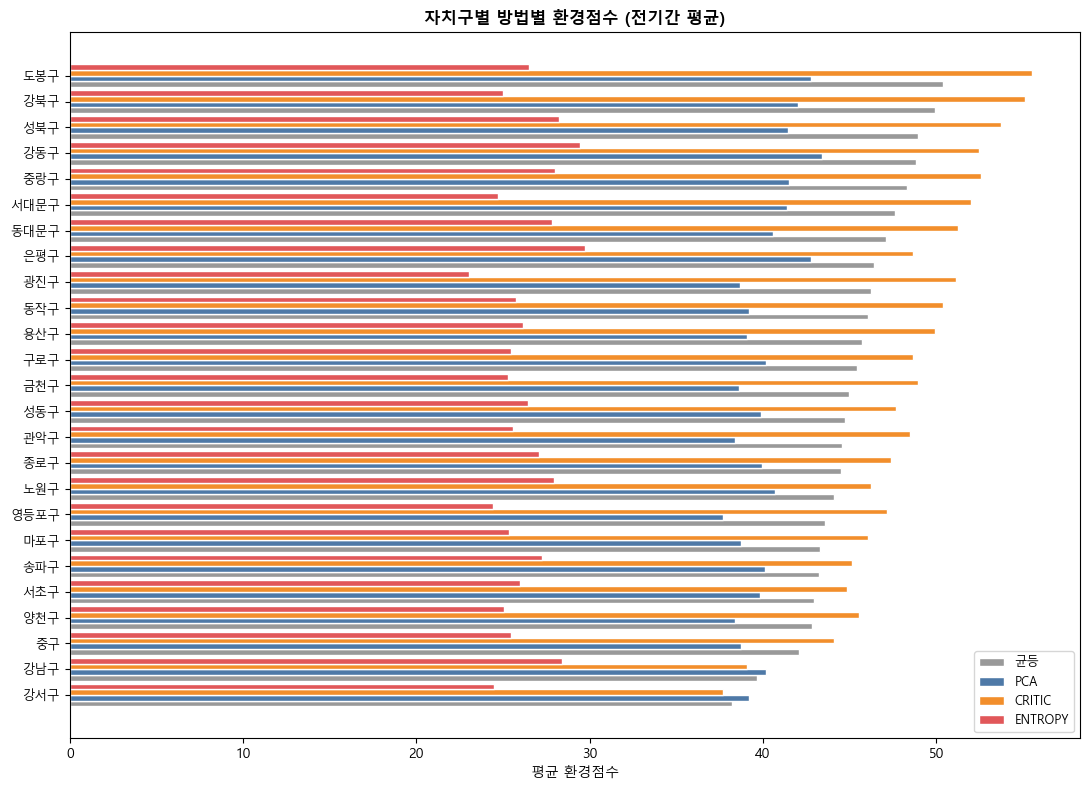

In [17]:
gu_avg = df.groupby('자치구')[SCORE_COLS].mean().round(2)
gu_avg.columns = [c.replace('환경점수_','') for c in SCORE_COLS]
gu_avg = gu_avg.sort_values('균등', ascending=True)
display(gu_avg)

fig, ax = plt.subplots(figsize=(11, 8))
xp = np.arange(len(gu_avg)); w = 0.22
clrs = ['#999999','#4e79a7','#f28e2b','#e15759']
for i, (col, color) in enumerate(zip(gu_avg.columns, clrs)):
    ax.barh(xp + i*w - 1.5*w, gu_avg[col], height=w, label=col, color=color, edgecolor='white')
ax.set_yticks(xp); ax.set_yticklabels(gu_avg.index, fontsize=9)
ax.set_xlabel('평균 환경점수')
ax.set_title('자치구별 방법별 환경점수 (전기간 평균)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

---
## 5. 자치구 순위 안정성 (민감도 분석)

,균등,PCA,CRITIC,ENTROPY
자치구,,,,
도봉구,1,3,1,10
강북구,2,4,2,21
성북구,3,6,3,4
강동구,4,1,5,2
중랑구,5,5,4,5
서대문구,6,7,6,22
동대문구,7,9,7,7
은평구,8,2,12,1
광진구,9,21,8,25


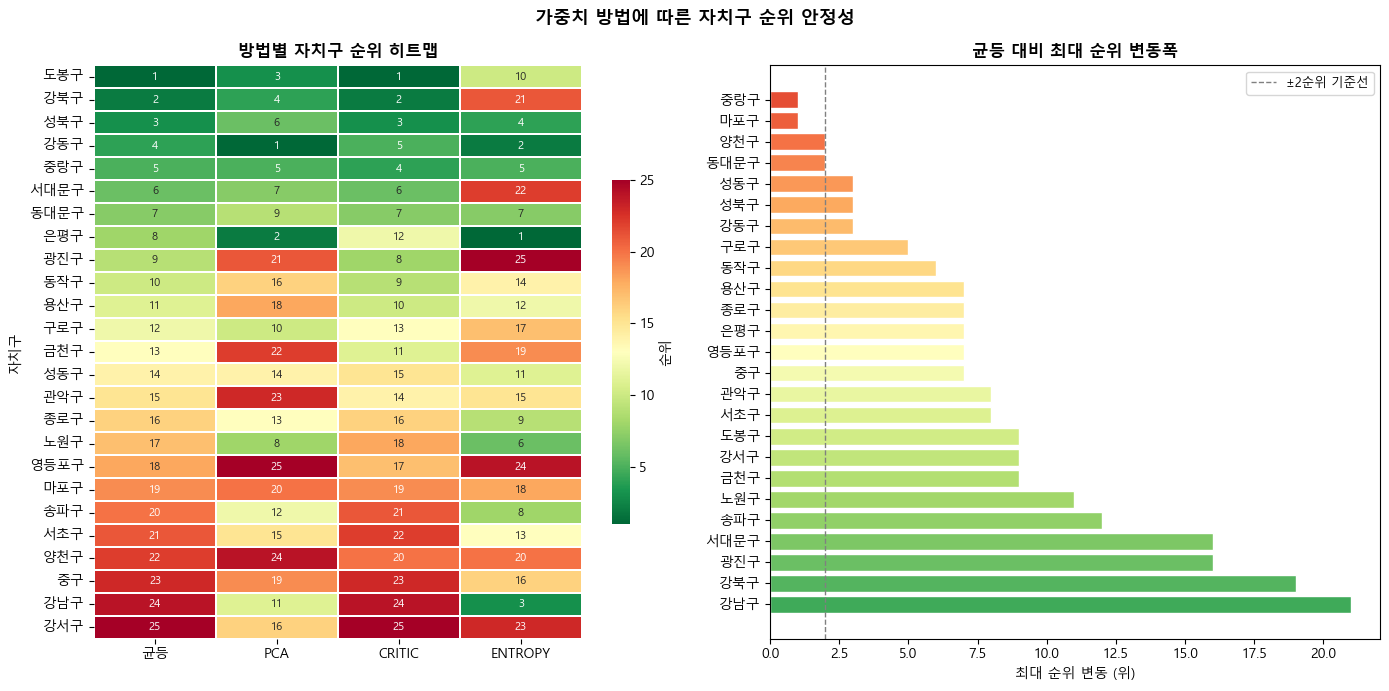

In [18]:
rank_df = gu_avg.rank(ascending=False).astype(int)
display(rank_df.sort_values('균등'))

diff = rank_df.subtract(rank_df['균등'], axis=0).drop(columns='균등').abs()
diff['최대변동'] = diff.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

sns.heatmap(rank_df.sort_values('균등'), ax=axes[0], annot=True, fmt='d',
    cmap='RdYlGn_r', linewidths=0.3, annot_kws={'size':8},
    cbar_kws={'label':'순위','shrink':0.6})
axes[0].set_title('방법별 자치구 순위 히트맵', fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)

diff_s = diff.sort_values('최대변동', ascending=False)
axes[1].barh(diff_s.index, diff_s['최대변동'],
    color=plt.cm.RdYlGn_r(np.linspace(0.15,0.85,len(diff_s))), edgecolor='white')
axes[1].axvline(2, color='gray', linestyle='--', lw=1, label='±2순위 기준선')
axes[1].set_title('균등 대비 최대 순위 변동폭', fontweight='bold')
axes[1].set_xlabel('최대 순위 변동 (위)'); axes[1].legend(fontsize=9)

plt.suptitle('가중치 방법에 따른 자치구 순위 안정성', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 6. 종합 요약 및 해석

In [19]:
base = '환경점수_균등'
print('=== 균등 가중치 대비 Spearman 순위 상관 ===')
for col in ['환경점수_PCA','환경점수_CRITIC','환경점수_ENTROPY']:
    r, _ = spearmanr(df[base], df[col])
    print(f'  균등 ↔ {col.replace("환경점수_","")}: r = {r:.4f}')

print()
summary = pd.DataFrame({
    '가중치 결정': {'균등':'고정(1/n)','PCA':'PC1 적재량','CRITIC':'변동성×비상관성','ENTROPY':'엔트로피 역수'},
    '최고 가중 변수': {
        '균등':'동일',
        'PCA': w_pca.idxmax(),
        'CRITIC': w_critic.idxmax(),
        'ENTROPY': w_entropy.idxmax(),
    },
    '점수 표준편차': df[SCORE_COLS].std().rename(
        lambda x: x.replace('환경점수_','')).round(2).to_dict(),
}).T
display(summary)

=== 균등 가중치 대비 Spearman 순위 상관 ===
  균등 ↔ PCA: r = 0.8874
  균등 ↔ CRITIC: r = 0.9381
  균등 ↔ ENTROPY: r = 0.7115



,균등,PCA,CRITIC,ENTROPY
가중치 결정,고정(1/n),PC1 적재량,변동성×비상관성,엔트로피 역수
최고 가중 변수,동일,불쾌지수점수,쓰레기점수,강수량점수
점수 표준편차,5.6,5.59,5.82,10.85
